# Loader danych rzeczywistych (.bin)

In [1]:
# ============================================================
# EVENT-BASED DATASET FOR N-CALTECH101 (.bin)
# Voxel grid representation for SNN
# ============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ============================================================
# 1. Loader .bin (N-Caltech101 format)
# ============================================================

def load_bin_events(path):
    """
    Reads N-Caltech101 .bin file
    Returns: x, y, t, p
    """
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]

    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)

    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)

    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid  = raw[3::5].astype(np.uint32)
    t_low  = raw[4::5].astype(np.uint32)

    t = (t_high << 16) | (t_mid << 8) | t_low
    t = t.astype(np.float32)

    return x, y, t, p


# ============================================================
# 2. Dataset
# ============================================================

class EventDatasetBIN(Dataset):
    """
    One sample = one .bin file
    Output: voxel grid [2, H, W, T] + label
    """

    def __init__(
        self,
        root_dir,
        classes,
        T=10,
        H=180,
        W=240,
        clip_value=5.0
    ):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            for f in class_dir.glob("*.bin"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_bin_events(path)

        # --- normalize time to [0, 1]
        t = t - t.min()
        t = t / (t.max() + 1e-9)

        # --- voxel grid [2, H, W, T]
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)

        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        # --- clip for stability
        voxels = np.clip(voxels, 0.0, self.clip_value)

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)


# ============================================================
# 3. DataLoader factory
# ============================================================

def make_dataloader(
    root_dir,
    classes,
    batch_size=4,
    shuffle=True,
    num_workers=0
):
    dataset = EventDatasetBIN(root_dir, classes)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        drop_last=False
    )
    return loader


# ============================================================
# 4. Test block
# ============================================================

if __name__ == "__main__":

    CLASSES = ["accordion", "airplanes", "brain", "camera", "elephant"]

    TRAIN_ROOT = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\train"
    TEST_ROOT  = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\test"

    train_loader = make_dataloader(
        TRAIN_ROOT,
        CLASSES,
        batch_size=4,
        shuffle=True
    )

    test_loader = make_dataloader(
        TEST_ROOT,
        CLASSES,
        batch_size=4,
        shuffle=False
    )

    X, y = next(iter(train_loader))
    print("Input shape:", X.shape)
    print("Labels:", y)


Input shape: torch.Size([4, 2, 180, 240, 10])
Labels: tensor([1, 1, 2, 1])


# Loader danych syntetycznych (.h5)

In [7]:
# ============================================================
# EVENT-BASED DATASET FOR v2e (.h5)
# Same voxel grid as for N-Caltech101
# ============================================================

import numpy as np
import torch
import h5py
from torch.utils.data import Dataset
from pathlib import Path

# ============================================================
# 1. Loader .h5 (v2e)
# ============================================================

def load_h5_events(path):
    """
    v2e .h5 loader
    Expected format: events = [t, x, y, p]
    """
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)

    p = data[:, 3]
    p = np.where(p > 0, 1, -1)

    return x, y, t, p


# ============================================================
# 2. Dataset (.h5 → voxel grid)
# ============================================================

class EventDatasetH5(Dataset):
    """
    One sample = one .h5 file
    Output: voxel grid [2, H, W, T] + label
    """

    def __init__(
        self,
        root_dir,
        classes,
        T=10,
        H=180,
        W=240,
        clip_value=5.0
    ):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_h5_events(path)

        # --- normalize time to [0, 1]
        t = t - t.min()
        t = t / (t.max() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

CLASSES = ["accordion", "airplanes", "brain", "camera", "elephant"]

dataset_h5 = EventDatasetH5(
    root_dir=r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS-5class-split\train",
    classes=CLASSES
)

X, y = dataset_h5[0]
print("Shape:", X.shape)
print("Label:", y)


Shape: torch.Size([2, 180, 240, 10])
Label: tensor(0)


# Testy Loadera dla danych ze zbioru NCaltech101

In [3]:
X, y = next(iter(train_loader))

print("Min:", X.min().item())
print("Max:", X.max().item())
print("Mean:", X.mean().item())
print("Non-zero ratio:", (X > 0).float().mean().item())

Min: 0.0
Max: 5.0
Mean: 0.10422222316265106
Non-zero ratio: 0.06548437476158142


In [4]:
on_events  = X[:, 0].sum().item()
off_events = X[:, 1].sum().item()

print("ON sum:", on_events)
print("OFF sum:", off_events)

ON sum: 177247.0
OFF sum: 182945.0


In [5]:
time_activity = X.sum(dim=(0,1,2,3))  # suma po batch, C, H, W
print("Activity per time bin:", time_activity)

Activity per time bin: tensor([3.2998e+04, 8.5417e+04, 2.0789e+04, 1.9463e+04, 8.9985e+04, 3.7257e+04,
        8.0870e+03, 3.8897e+04, 2.7295e+04, 4.0000e+00])


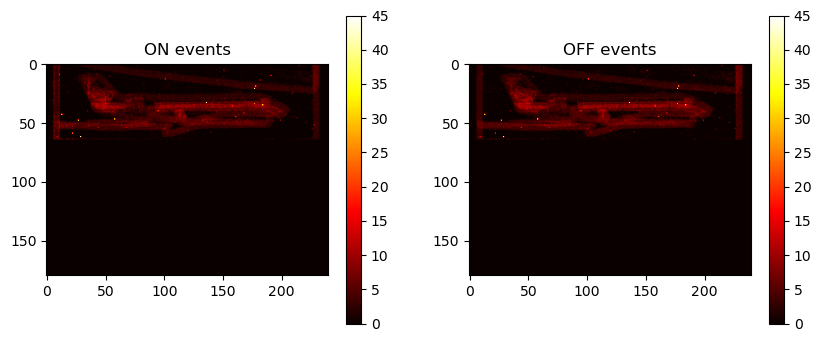

In [6]:
import matplotlib.pyplot as plt

sample = X[0]  # [2, H, W, T]

img_on  = sample[0].sum(dim=-1)
img_off = sample[1].sum(dim=-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_on, cmap="hot")
plt.title("ON events")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(img_off, cmap="hot")
plt.title("OFF events")
plt.colorbar()

plt.show()

# Testy dla zbioru syntetycznego

In [8]:
print("Min:", X.min().item())
print("Max:", X.max().item())
print("Mean:", X.mean().item())
print("Non-zero ratio:", (X > 0).float().mean().item())

Min: 0.0
Max: 5.0
Mean: 0.3487604260444641
Non-zero ratio: 0.18917708098888397


In [9]:
print("ON sum:", X[0].sum().item())
print("OFF sum:", X[1].sum().item())

ON sum: 163385.0
OFF sum: 137944.0


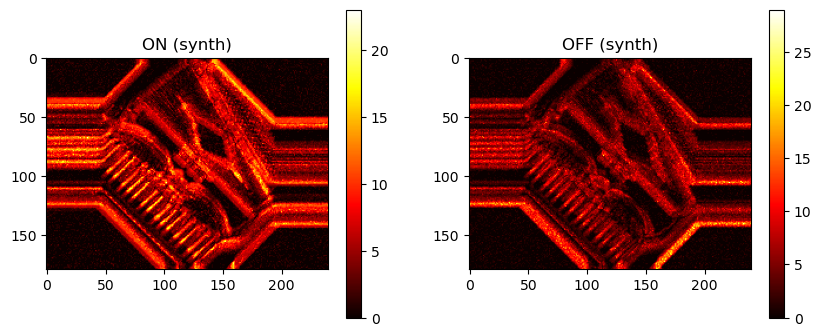

In [10]:
import matplotlib.pyplot as plt

img_on  = X[0].sum(dim=-1)
img_off = X[1].sum(dim=-1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_on, cmap="hot")
plt.title("ON (synth)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(img_off, cmap="hot")
plt.title("OFF (synth)")
plt.colorbar()
plt.show()

# Loader danych rzeczywistych (.bin) z normalizacją

In [1]:
# ============================================================
# EVENT-BASED DATASET FOR N-CALTECH101 (.bin)
# Voxel grid representation for SNN
# ============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ============================================================
# 1. Loader .bin (N-Caltech101 format)
# ============================================================

def load_bin_events(path):
    """
    Reads N-Caltech101 .bin file
    Returns: x, y, t, p
    """
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]

    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)

    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)

    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid  = raw[3::5].astype(np.uint32)
    t_low  = raw[4::5].astype(np.uint32)

    t = (t_high << 16) | (t_mid << 8) | t_low
    t = t.astype(np.float32)

    return x, y, t, p


# ============================================================
# 2. Dataset
# ============================================================

class EventDatasetBIN(Dataset):
    """
    One sample = one .bin file
    Output: voxel grid [2, H, W, T] + label
    """

    def __init__(
        self,
        root_dir,
        classes,
        T=10,
        H=180,
        W=240,
        clip_value=5.0
    ):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            for f in class_dir.glob("*.bin"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_bin_events(path)

        # --- normalize time to [0, 1]
        t = t - t.min()
        t = t / (t.max() + 1e-9)

        # --- voxel grid [2, H, W, T]
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)

        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        # --- clip for stability
        voxels = np.clip(voxels, 0.0, self.clip_value)
        
        voxels = voxels / self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)


# ============================================================
# 3. DataLoader factory
# ============================================================

def make_dataloader(
    root_dir,
    classes,
    batch_size=4,
    shuffle=True,
    num_workers=0
):
    dataset = EventDatasetBIN(root_dir, classes)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        drop_last=False
    )
    return loader


# ============================================================
# 4. Test block
# ============================================================

if __name__ == "__main__":

    CLASSES = ["accordion", "airplanes", "brain", "camera", "elephant"]

    TRAIN_ROOT = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\train"
    TEST_ROOT  = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101-5class-split\test"

    train_loader = make_dataloader(
        TRAIN_ROOT,
        CLASSES,
        batch_size=4,
        shuffle=True
    )

    test_loader = make_dataloader(
        TEST_ROOT,
        CLASSES,
        batch_size=4,
        shuffle=False
    )

    X, y = next(iter(train_loader))
    print("Input shape:", X.shape)
    print("Labels:", y)


Input shape: torch.Size([4, 2, 180, 240, 10])
Labels: tensor([4, 0, 1, 1])


# Loader danych syntetycznych (.h5) z normalizacją

In [2]:
# ============================================================
# EVENT-BASED DATASET FOR v2e (.h5)
# Same voxel grid as for N-Caltech101
# ============================================================

import numpy as np
import torch
import h5py
from torch.utils.data import Dataset
from pathlib import Path

# ============================================================
# 1. Loader .h5 (v2e)
# ============================================================

def load_h5_events(path):
    """
    v2e .h5 loader
    Expected format: events = [t, x, y, p]
    """
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)

    p = data[:, 3]
    p = np.where(p > 0, 1, -1)

    return x, y, t, p


# ============================================================
# 2. Dataset (.h5 → voxel grid)
# ============================================================

class EventDatasetH5(Dataset):
    """
    One sample = one .h5 file
    Output: voxel grid [2, H, W, T] + label
    """

    def __init__(
        self,
        root_dir,
        classes,
        T=10,
        H=180,
        W=240,
        clip_value=5.0
    ):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_h5_events(path)

        # --- normalize time to [0, 1]
        t = t - t.min()
        t = t / (t.max() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        
        voxels = voxels / self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

CLASSES = ["accordion", "airplanes", "brain", "camera", "elephant"]

dataset_h5 = EventDatasetH5(
    root_dir=r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS-5class-split\train",
    classes=CLASSES
)

X, y = dataset_h5[0]
print("Shape:", X.shape)
print("Label:", y)


Shape: torch.Size([2, 180, 240, 10])
Label: tensor(0)


# Testy dla loaderów

In [3]:
from tqdm import tqdm # do paska postępu

def get_dataset_stats(loader):
    print("Obliczanie statystyk... Może to chwilę potrwać.")
    
    all_min = float('inf')
    all_max = float('-inf')
    total_sum = 0.0
    total_elements = 0
    non_zero_sum = 0.0
    non_zero_count = 0

    # Iterujemy przez cały loader
    for images, _ in tqdm(loader):
        # images ma kształt [batch_size, 2, H, W, T]
        
        # Aktualizacja min i max
        current_min = images.min().item()
        current_max = images.max().item()
        if current_min < all_min: all_min = current_min
        if current_max > all_max: all_max = current_max
        
        # Aktualizacja średniej globalnej
        total_sum += images.sum().item()
        total_elements += images.numel()
        
        # Opcjonalnie: średnia tylko dla niezerowych wartości (fajne dla eventów)
        non_zero_mask = images > 0
        non_zero_sum += images[non_zero_mask].sum().item()
        non_zero_count += non_zero_mask.sum().item()

    global_mean = total_sum / total_elements
    non_zero_mean = non_zero_sum / non_zero_count if non_zero_count > 0 else 0

    return {
        "min": all_min,
        "max": all_max,
        "mean": global_mean,
        "non_zero_mean": non_zero_mean,
        "sparsity_%": (1 - non_zero_count / total_elements) * 100
    }

In [4]:
# Sprawdzenie dla danych rzeczywistych (N-Caltech101)
print("--- Statystyki: N-Caltech101 (Real) ---")
train_loader_real = make_dataloader(TRAIN_ROOT, CLASSES, batch_size=8, num_workers=0)
stats_real = get_dataset_stats(train_loader_real)
print(stats_real)

# Sprawdzenie dla danych syntetycznych (v2e)
print("\n--- Statystyki: v2e (Synthetic) ---")
# Tworzymy loader dla H5
dataset_h5 = EventDatasetH5(
    root_dir=r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS-5class-split\train",
    classes=CLASSES
)
loader_h5 = DataLoader(dataset_h5, batch_size=8, shuffle=False)

stats_h5 = get_dataset_stats(loader_h5)
print(stats_h5)

--- Statystyki: N-Caltech101 (Real) ---
Obliczanie statystyk... Może to chwilę potrwać.


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [03:04<00:00,  1.72s/it]


{'min': 0.0, 'max': 1.0, 'mean': 0.019979564578465572, 'non_zero_mean': 0.34248220952671177, 'sparsity_%': 94.16624753050236}

--- Statystyki: v2e (Synthetic) ---
Obliczanie statystyk... Może to chwilę potrwać.


100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [03:15<00:00,  1.83s/it]

{'min': 0.0, 'max': 1.0, 'mean': 0.020082323723705615, 'non_zero_mean': 0.27943945177862906, 'sparsity_%': 92.81335387629717}


# Wagi klas

In [3]:
import torch
from collections import Counter

def compute_class_weights(dataset, num_classes):
    labels = [label for _, label in dataset.samples]
    counts = Counter(labels)

    total = sum(counts.values())
    weights = []

    for c in range(num_classes):
        w = total / (num_classes * counts[c])
        weights.append(w)

    return torch.tensor(weights, dtype=torch.float32)


In [4]:
train_dataset_real = EventDatasetBIN(
    root_dir=TRAIN_ROOT,
    classes=CLASSES
)

class_weights_real = compute_class_weights(
    train_dataset_real,
    num_classes=len(CLASSES)
)

print("Class weights (REAL):", class_weights_real)


Class weights (REAL): tensor([3.8773, 0.2666, 2.1872, 4.2650, 3.3451])
